In [2]:
import itertools
import csv

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from torchquad import (
    set_up_backend,
    Trapezoid,
    Simpson,
    MonteCarlo,
    Gaussian,
    GaussLegendre,
)
import torch
from torch import exp, sin, cos

## Memorijska funkcija s vezanjem $\theta(k_c-|k-k'|)$


In [142]:
set_up_backend("torch", data_type="float32")
tp = Trapezoid()

## Konstante i osnovne funkcije

In [147]:
kb = 8.6173303 * 10 ** (-5)
hbar = 6.582119569 * 10 ** (-16)
pi = np.pi

alpha_op = 0.4
alpha_ac = 1
hbar_w_op = torch.Tensor([0.4]).to("cuda")
eta_0 = 1 * 10 ** (-3)
M = 0.0
Kf_20 = 0.2  # eV, Fermi at 20K
vf = 4 * 10**5
a = 100 ** (1 / 3) * 10 ** (-10)
T_0 = 4
T_F = Kf_20 / kb
W = 1  # band width
c = 3500

Kf_ = Kf_20 / hbar / vf * a  # Fermi unitless
K_c = Kf_  # cutoff for coupling unitless
Kf_max = W / hbar / vf * a  # cutoff 1eV unitless
c_s_tilde = hbar * c / a  # hbar_w_ac_max / hbar / vf * a
hbar_w_ac_max = c_s_tilde * hbar * vf / a
G_op2 = alpha_op
G_ac2 = alpha_ac * hbar * vf / a

Ef = torch.sqrt(torch.FloatTensor([Kf_20**2 + M**2])).to("cuda")

In [5]:
def arrays_to_csv(array1, array2, name):
    with open(f"{name}.csv", "w", newline="") as file:
        writer = csv.writer(file)
        for a1, a2 in zip(array1, array2):
            writer.writerow([round(a1, 5), a2])


def read_from_csv(name):
    col_1 = []
    col_2 = []
    with open(f"{name}.csv", "r", newline="") as file:
        reader = csv.reader(file)
        for a1, a2 in reader:
            col_1.append(float(a1))
            col_2.append(float(a2))
    return col_1, col_2

In [122]:
def fermi_dirac(E, Ef, T):
    if T > 0:
        return torch.where(
            E > Ef,
            exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1),
            1 / (exp((E - Ef) / (kb * T)) + 1),
        )
    else:
        return torch.where(E > Ef, 0, 1)


def d_fermi_dirac(E, Ef, T):
    return 1 / kb / T * fermi_dirac(E, Ef, T) * (1 - fermi_dirac(E, Ef, T))


def bose_einstein(E, T):
    if T == 0:
        return 0
    return torch.where(E > 0, exp(-E / (kb * T)) / (-exp(-E / (kb * T)) + 1), 0)


def chemical_potential(T):
    return (
        Ef
        - pi**2 / 6 * (2 * Ef**2 - M**2) / Ef / (Ef**2 - M**2) * (kb * T) ** 2
        - 7 / 360 * pi**4 * 3 * M**4 / Ef / (Ef**2 - M**2) ** 3 * (kb * T) ** 4
    )


def eps(K):
    arg = hbar**2 * vf**2 / a**2 * K**2 + M**2
    if isinstance(K, torch.Tensor):
        return torch.sqrt(arg)
    else:
        return np.sqrt(arg)


def eff_concetration(T):
    def integrand(k):
        return 2 / hbar / vf / a**2 * fermi_dirac(eps(k), Ef, T) * k

    return (
        4
        * pi
        / 3
        * 2
        / (2 * pi) ** 3
        * vf**2
        * integrate.quad(integrand, 0, Kf_max, limit=80000)[0]
    )


def coupling(K_c, abs_dK):
    return G_op2 / (1 + exp(-10000 * (K_c - abs_dK)))


def hbar_ac(K):
    return c_s_tilde * K

In [123]:
print(eff_concetration(0))  # T=0 numerički
print(4 * pi / 3 * 2 / (2 * pi) ** 3 * Kf_20**2 / hbar**3 / vf)  # T=0 analitički

1.1843544863015165e+37
1.184354454914293e+37


In [124]:
ws_0 = torch.arange(0, 1, 0.01)
from tqdm import tqdm_notebook


def calculate_integral_points(
    mem_fn, real_sum, imag_sum, hbar_w_ph, T=T_0, eta=eta_0, ws=ws_0, u=Kf_20, K_c=K_c
):

    result_real = []

    result_imag = []

    for w in tqdm_notebook(ws):

        result_real.append(
            mem_fn(real_sum, w, hbar_w_ph, u, T=T, eta=eta, K_c=K_c).to("cpu")
        )

        result_imag.append(
            mem_fn(imag_sum, w, hbar_w_ph, u, T=T, eta=eta, K_c=K_c).to("cpu")
        )

    return result_real, result_imag


def setup_plot(real=True, imag=True, x_lim=[0.0, 0.05], y_lim=[0, 0.06]):

    fig, ax1 = plt.subplots()

    ax1.set_xlabel(r"$\hbar \omega [eV]$")

    if real:

        ax1.set_ylabel(r"$\hbar Re\{M_x\} [eV]$")

    else:

        ax1.set_ylabel(r"$\hbar Im\{M_x\} [eV]$")

    ax1.set_xlim(x_lim)

    ax1.set_ylim(y_lim)

    if imag and real:

        ax2 = ax1.twinx()

        ax2.set_ylabel(r"$\hbar Im\{M_x\} [eV]$")

        ax2.set_xlim(x_lim)

        ax2.set_ylim(y_lim)

        return fig, ax1, ax2

    return fig, ax1


def plot_real_and_imag_result(
    ax1, ax2, result_real, result_imag, T=None, eta=None, ws=ws_0
):
    assert T or eta

    ax1.plot(
        ws.to("cpu"), result_real, label=f"T={T} K" if T else f"$\eta = $ {eta:.4f} eV"
    )

    ax2.plot(ws.to("cpu"), result_imag)

    if T:

        plt.text(0.020, 0.002, f"$\eta = $ {eta_0:.4f} $eV$", fontsize=10)

    else:

        plt.text(0.020, 0.002, f"T={T_0} K", fontsize=10)


def plot_result(ax, result, T=None, eta=None, ws=ws_0):

    ax.plot(
        ws.to("cpu"),
        result,
        label=f"$T=${T} K" if T is not None else f"$\eta = $ {eta:.5f} eV",
    )

<>:65: SyntaxWarning: invalid escape sequence '\e'
<>:72: SyntaxWarning: invalid escape sequence '\e'
<>:84: SyntaxWarning: invalid escape sequence '\e'
<>:65: SyntaxWarning: invalid escape sequence '\e'
<>:72: SyntaxWarning: invalid escape sequence '\e'
<>:84: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Patrik\AppData\Local\Temp\ipykernel_10672\2754146150.py:65: SyntaxWarning: invalid escape sequence '\e'
  ws.to("cpu"), result_real, label=f"T={T} K" if T else f"$\eta = $ {eta:.4f} eV"
C:\Users\Patrik\AppData\Local\Temp\ipykernel_10672\2754146150.py:72: SyntaxWarning: invalid escape sequence '\e'
  plt.text(0.020, 0.002, f"$\eta = $ {eta_0:.4f} $eV$", fontsize=10)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_10672\2754146150.py:84: SyntaxWarning: invalid escape sequence '\e'
  label=f"$T=${T} K" if T is not None else f"$\eta = $ {eta:.5f} eV",


## Akustični fononi


**Memorijska funkcija**

In [125]:
def ss_sum_part(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c):
    abs_k_k_ = torch.sqrt(K**2 + K_**2 - 2 * K * K_ * cos(alpha))

    def summand(s1, s2):

        return (
            (
                bose_einstein(hbar_w_ph(abs_k_k_), T)
                + fermi_dirac(s1 * s2 * eps(K), s1 * s2 * u, T)
            )
            / (
                hbar_w
                + s1 * eps(K_)
                - s1 * eps(K)
                + s2 * hbar_w_ph(abs_k_k_)
                + eta * 1j
            )
            * coupling(K_c, abs_k_k_)
        )

    sum = 0

    for s1, s2 in itertools.product([-1, 1], [-1, 1]):

        sum = sum + summand(s1, s2)

    return (
        sum
        * K**2
        * K_**2
        * sin(alpha)
        * (1 - cos(alpha))
        * d_fermi_dirac(eps(K_), Ef, T)
    )


def ss_sum_real(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c):

    return ss_sum_part(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c).real


def ss_sum_imag(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c):

    return ss_sum_part(K_, K, alpha, hbar_w, hbar_w_ph, T, u, eta, K_c).imag


def mem_fn_op(ss_sum_fn, hbar_w, hbar_w_ph, u, T, eta, K_c):

    integration_domain = torch.Tensor(
        [
            [Kf_ - 0.003, Kf_ + 0.003],
            [0, Kf_max],
            [0, pi],
        ]
    )

    def integrand(K):

        return ss_sum_fn(
            K[:, 0],
            K[:, 1],
            K[:, 2],
            hbar_w,
            hbar_w_ph,
            T,
            u,
            eta,
            K_c,
        )

    integral_k_k_ = tp.integrate(
        integrand,
        dim=3,
        N=10**7 * 2,
        integration_domain=integration_domain,
    )

    return (
        (1 / eff_concetration(T) / a**3 * 2 / (2 * pi) ** 3 * vf**2)
        * (-1 / (2 * pi) ** 3)
        * (8 / 3 * pi**2)
        * integral_k_k_
    )

C:\Users\Patrik\AppData\Local\Temp\ipykernel_10672\2754146150.py:13: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\Patrik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchquad\integration\utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(
C:\Users\Patrik\AppData\Local\Temp\ipykernel_10672\700752049.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.array(ws_0.to("cpu")),
C:\Users\Patrik\AppData\Local\Temp\ipykernel_10672\700752049.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.array(ws_0.to("cpu")),


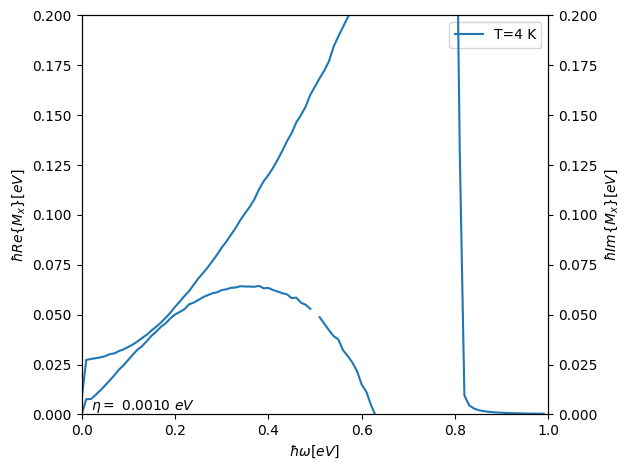

In [126]:
fig, *axs = setup_plot(x_lim=[0, 1], y_lim=[0, 0.2])
integrals = calculate_integral_points(
    mem_fn_op, ss_sum_real, ss_sum_imag, hbar_ac, T=T_0, K_c=50 * Kf_
)
arrays_to_csv(
    np.array(ws_0.to("cpu")),
    np.array(integrals[0]),
    f"op-g2, real, T={T_0}K, eta={eta_0}eV",
)
arrays_to_csv(
    np.array(ws_0.to("cpu")),
    list(np.array(integrals[1])),
    f"op-g2, imag, T={T_0}K, eta={eta_0}eV",
)
plot_real_and_imag_result(*axs, *integrals, T=T_0)
axs[0].legend(loc="best")
fig.tight_layout()

(0.0, 0.05)

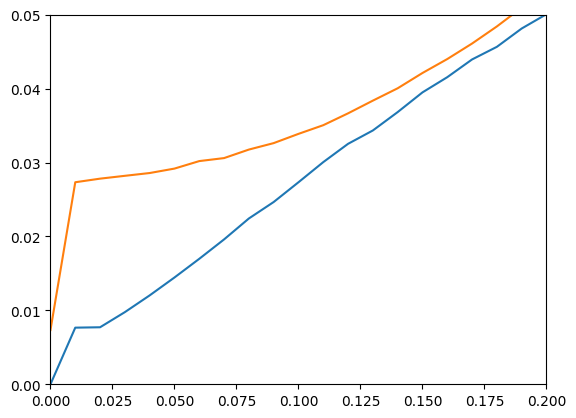

In [129]:
plt.plot(ws_0.to("cpu"), integrals[0])
plt.plot(ws_0.to("cpu"), integrals[1])
plt.xlim(0, 0.2)
plt.ylim(0, 0.05)

C:\Users\Patrik\AppData\Local\Temp\ipykernel_8168\1564089390.py:13: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

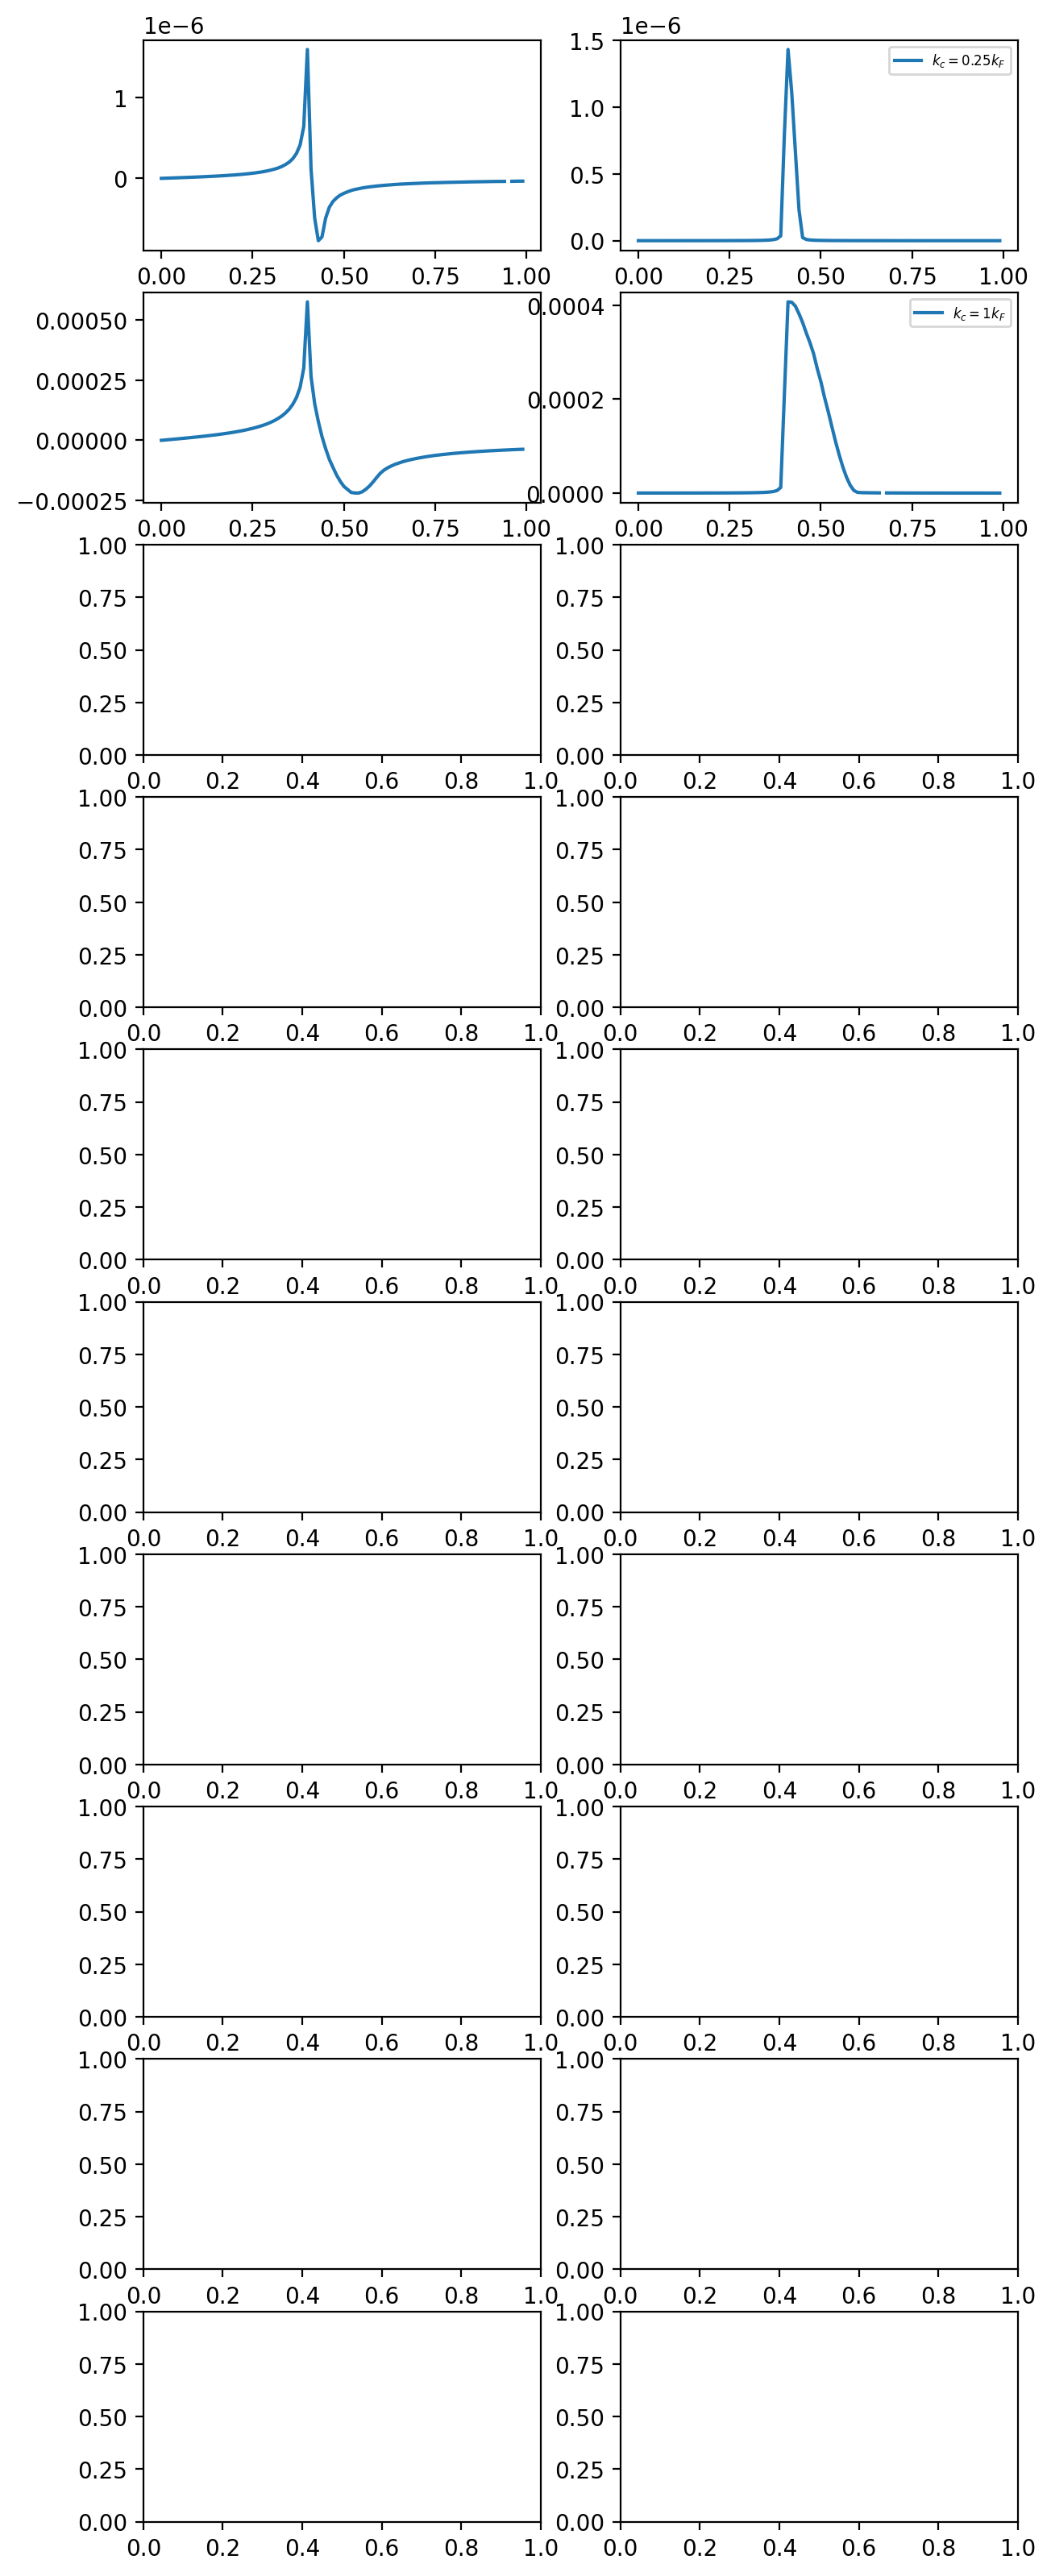

In [31]:
fig, ax = plt.subplots(10, 2, figsize=(7, 20), dpi=200)
for i, kc in enumerate([1 / 4, 1, 1.5, 2, 2.5, 3, 3.5, 4.25, 5, 8]):
    integrals = calculate_integral_points(
        mem_fn_op, ss_sum_real, ss_sum_imag, hbar_w_op, K_c=kc * Kf_
    )
    ax[i, 0].plot(ws_0.cpu(), integrals[0], label=f"$k_c={kc} k_F$")
    ax[i, 1].plot(ws_0.cpu(), integrals[1], label=f"$k_c={kc} k_F$")
    ax[i, 1].legend(loc="upper right", prop={"size": 6})
plt.tight_layout()
plt.show()

## Analitički

In [95]:
def mem_fn_imag_anal(hbar_w, k_w, k_c, k_f):
    faktor = a**3 * G_op2 / (8 * pi * c * k_f**2) / hbar**2

    def poli(x, s):
        return (
            1
            / 12
            / c**3
            * (
                x**4 * (3 * vf**3 - 3 * c**2 * s * vf)
                + x**3
                * (
                    (4 * c**2 - 12 * vf**2) * hbar_w
                    - 12 * k_f * s * vf**3
                    + 12 * c**2 * k_f * vf
                )
                + x**2
                * (
                    18 * s * vf * (hbar_w) ** 2
                    + (36 * k_f * vf**2 - 12 * c**2 * k_f) * hbar_w
                    + 18 * k_f**2 * s * vf**3
                    - 18 * c**2 * k_f**2 * s * vf
                )
                + x
                * (
                    -12 * (hbar_w) ** 3
                    - 36 * k_f * s * vf * (hbar_w) ** 2
                    + (12 * c**2 * k_f**2 - 36 * k_f**2 * vf**2) * (hbar_w)
                    - 12 * k_f**3 * s * vf**3
                    + 12 * c**2 * k_f**3 * s * vf
                )
            )
        )

    rez = 0
    for s in (1, -1):
        phi_min = torch.maximum(
            torch.maximum(
                torch.tensor([0]),
                (s * (hbar_w) / c + (vf / c - 1) * k_f) / (vf / c + 1),
            ),
            s * (hbar_w) / vf + k_f - k_c * c / vf,
        )
        phi_max = torch.minimum(
            k_f, (s * (hbar_w) / c + (vf / c - 1) * k_f) / (vf / c - 1)
        ) * torch.where(
            (s * (hbar_w) / c + (vf / c - 1) * k_f) / (vf / c - 1) > 0, 1, 0
        )
        rez += s * poli(phi_max, s) - s * poli(phi_min, s)
    for s in (1, -1):
        phi_min = torch.maximum(
            torch.maximum(k_w, (s * (hbar_w) / c + (-vf / c + 1) * k_f) / (vf / c + 1)),
            -s * (hbar_w) / vf + k_f + k_c * c / vf,
        )

        phi_max = torch.minimum(
            k_f, (s * (hbar_w) / c + (vf / c + 1) * k_f) / (vf / c - 1)
        )

        rez += s * poli(phi_max, -s) - s * poli(phi_min, -s)
    return -(faktor * rez * hbar) / hbar**2

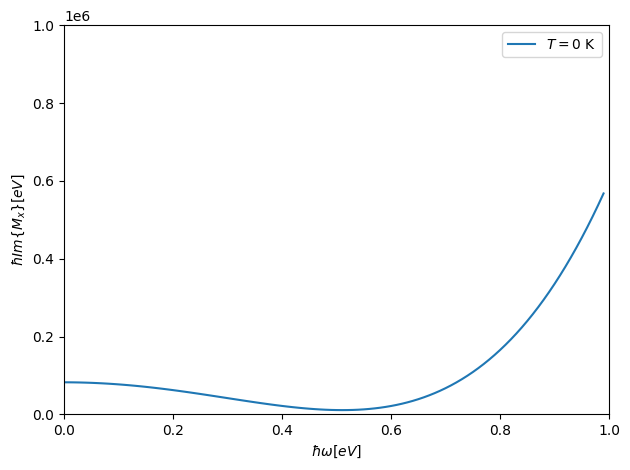

In [105]:
fig, ax = setup_plot(real=False, x_lim=[0, 1], y_lim=[0, 1000000])
values = list(
    mem_fn_imag_anal(
        ws_0,
        k_w=torch.tensor([W / vf]),
        k_c=3 * Ef / vf,
        k_f=torch.tensor([Kf_20 / vf]),
    ).to("cpu")
)
plot_result(ax, values, T=0)
# numeric_values = read_from_csv("op-g2, imag, T=4K, eta=0.001eV")[1]
# ax.plot(
#     ws_0[::].to("cpu"),
#     numeric_values,
#     linestyle="--",
#     label=f"$T={T_0}$ K",
# )
# plt.text(0.2, 0.08, f"$\epsilon _w=${W} eV")
# plt.text(0.2, 0.075, f"$\epsilon _c={3*float(Ef):.1f}$ eV")
# plt.text(0.2, 0.07, f"$\epsilon _F={float(Ef):.1f}$ eV")

ax.legend(loc="best")
fig.tight_layout()

In [97]:
mem_fn_imag_anal(
    ws_0,
    k_w=torch.tensor([W / vf]),
    k_c=3 * Ef / vf,
    k_f=torch.tensor([Kf_20 / vf]),
)

tensor([ 794301.8125,  793697.3125,  792072.6250,  789428.1875,  785767.5000,
         781096.0625,  775421.7500,  768755.0000,  761109.1875,  752500.0625,
         742945.1250,  732465.1875,  721083.6875,  708826.1250,  695720.2500,
         681796.8125,  667088.7500,  651632.1250,  635464.4375,  618626.9375,
         601162.3125,  583116.1250,  564536.2500,  545473.6250,  525981.0000,
         506113.1875,  485928.5625,  465486.7812,  444850.5625,  424085.0625,
         403257.3750,  382437.5625,  361697.9062,  341113.0000,  320759.9688,
         300718.4688,  281070.2500,  261899.7031,  243293.8594,  225341.7656,
         208135.1250,  191768.0781,  176337.0938,  161941.0781,  148681.1250,
         136661.6562,  125988.3047,  116770.0781,  109117.3359,  103144.2578,
          98966.6562,   96702.7344,   96473.0547,   98400.8281,  102612.2344,
         109234.7656,  118398.3516,  130236.9688,  144885.0938,  162480.6250,
         183164.2812,  207077.7500,  234366.8281,  265177.5000, 

In [102]:
c_s_tilde * a / hbar

21155.444465670626

In [148]:
def anint(w, k_w, k_c, k_f):
    def integrand(k):
        rez = 0
        for s in (1, -1):
            for s_ in (1, -1):
                rez += (
                    (
                        (s * s_ * vf / c * (k - k_f) - s_ * w / c) ** 3
                        - (s * s_ * vf / c * (k - k_f) - s_ * w / c) * (k_f - k) ** 2
                    )
                    * torch.where(
                        s * s_ * (k_f - k) > 0,
                        1,
                        0,
                    )
                    * torch.where(
                        k_c > s * s_ * vf / c * (k - k_f) - s_ * w / c,
                        1,
                        0,
                    )
                    * torch.where(
                        s * s_ * vf / c * (k - k_f) - s_ * w / c - abs(k_f - k) > 0,
                        1,
                        0,
                    )
                    * torch.where(
                        -s * s_ * vf / c * (k - k_f) + s_ * w / c + k_f + k,
                        1,
                        0,
                    )
                )
        return a**3 * G_op2 / (8 * k_f**2 * hbar**2 * c * pi) * rez

    integration_domain = torch.Tensor(
        [
            [0, k_w],
        ]
    )
    return tp.integrate(
        integrand,
        dim=1,
        N=10**3,
        integration_domain=integration_domain,
    )

In [149]:
res = anint(
    ws_0 / hbar,
    k_w=torch.tensor([W / vf / hbar]),
    k_c=3 * Ef / vf / hbar,
    k_f=torch.tensor([Kf_20 / vf / hbar]),
)

RuntimeError: where expected condition to be a boolean tensor, but got a tensor with dtype Float